In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import random
from collections import deque
from tqdm import tqdm  
import pandas as pd
import copy

In [2]:
P_0_matrix=np.array([[0.1,0.9,0,0,0],
                   [0.1,0,0.9,0,0],
                   [0.1,0,0,0.9,0],
                   [0.1,0,0,0,0.9],
                   [0.1,0,0,0,0.9]])
P_0_matrix


array([[0.1, 0.9, 0. , 0. , 0. ],
       [0.1, 0. , 0.9, 0. , 0. ],
       [0.1, 0. , 0. , 0.9, 0. ],
       [0.1, 0. , 0. , 0. , 0.9],
       [0.1, 0. , 0. , 0. , 0.9]])

In [3]:
P_1_matrix=np.array([[1,0,0,0,0],
                   [1,0,0,0,0],
                   [1,0,0,0,0],
                   [1,0,0,0,0],
                   [1,0,0,0,0]])
P_1_matrix

array([[1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0]])

In [4]:
action_space=[0,1]
state_space=[0,1,2,3,4]
A=0.9
reward_matrix=[[A**1,0],[A**2,0],[A**3,0],[A**4,0],[A**5,0]]
N=10
M=2
epsilon=1
subsidy=0
arm_indexes=[i for i in range(N)]
gamma=0.99

In [5]:
def step(state,state_space,action,P_0_matrix,P_1_matrix,reward_matrix):
  new_state=state
  if(action==1):
    new_state=np.random.choice(state_space,replace=True,p=P_1_matrix[state])
    reward=reward_matrix[state][1]
  else:
    new_state=np.random.choice(state_space,replace=True,p=P_0_matrix[state])
    reward=reward_matrix[state][0]
  return [new_state,reward]

In [6]:
Q_values=[]
for i in range(N):
  Q_values.append([[A**1,0],[A**2,0],[A**3,0],[A**4,0],[A**5,0]])

In [7]:
Q_values

[[[0.9, 0],
  [0.81, 0],
  [0.7290000000000001, 0],
  [0.6561, 0],
  [0.5904900000000001, 0]],
 [[0.9, 0],
  [0.81, 0],
  [0.7290000000000001, 0],
  [0.6561, 0],
  [0.5904900000000001, 0]],
 [[0.9, 0],
  [0.81, 0],
  [0.7290000000000001, 0],
  [0.6561, 0],
  [0.5904900000000001, 0]],
 [[0.9, 0],
  [0.81, 0],
  [0.7290000000000001, 0],
  [0.6561, 0],
  [0.5904900000000001, 0]],
 [[0.9, 0],
  [0.81, 0],
  [0.7290000000000001, 0],
  [0.6561, 0],
  [0.5904900000000001, 0]],
 [[0.9, 0],
  [0.81, 0],
  [0.7290000000000001, 0],
  [0.6561, 0],
  [0.5904900000000001, 0]],
 [[0.9, 0],
  [0.81, 0],
  [0.7290000000000001, 0],
  [0.6561, 0],
  [0.5904900000000001, 0]],
 [[0.9, 0],
  [0.81, 0],
  [0.7290000000000001, 0],
  [0.6561, 0],
  [0.5904900000000001, 0]],
 [[0.9, 0],
  [0.81, 0],
  [0.7290000000000001, 0],
  [0.6561, 0],
  [0.5904900000000001, 0]],
 [[0.9, 0],
  [0.81, 0],
  [0.7290000000000001, 0],
  [0.6561, 0],
  [0.5904900000000001, 0]]]

In [8]:
def Q_value_update(Q_values,state,next_state,action,reward,arm_index,subsidy,alpha):
  if action==1:
    Q_values[arm_index][state][action]=(1-alpha)*(Q_values[arm_index][state][action])+alpha*(reward+max(Q_values[arm_index][next_state])-(np.array(Q_values[arm_index]).sum())/8)
  else:
    Q_values[arm_index][state][action]=(1-alpha)*(Q_values[arm_index][state][action])+alpha*(reward+subsidy+max(Q_values[arm_index][next_state])-(np.array(Q_values[arm_index]).sum())/8)
  return Q_values



In [9]:
def act(Q_values,epsilon,state,arm_index):
  decision=np.random.binomial(n=1,p=epsilon,size=1)
  if decision==1:
    action=random.choice([0,1])
  else:
    action=np.argmax(Q_values[arm_index][state])
  return action

In [10]:
rewards=[]
subsidies=[]
action_sums=[]
betas=[]
alphas=[]
epsilon=1

In [11]:
whittle_indexes=[]
for _ in range(N):
    whittle_indexes.append([0 for _ in range(len(state_space))])

current_state=[0 for _ in range(N)]
whittle_indexes

[[0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0]]

In [12]:
whittle_indexes_over_time=[]
whittle_indexes_over_time.append(copy.deepcopy(whittle_indexes))
whittle_indexes_over_time

[[[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0]]]

In [13]:
for i in range(1,1000001):
  # top_M_indices=act(alternative_indexes,N,M,epsilon)
  action_sum=0
  reward_sum=0
  alpha=1/(1+(i/20000))
  if i%50==0:
    beta=1/(1+(i*np.log(i)/20000))
  else:
    beta=0
  epsilon=0.1
  for index in arm_indexes:
      # action=np.argmax(Q_values[index][current_state[index]])
      action=act(Q_values,epsilon,current_state[index],index)

      action_sum+=action
      x=step(current_state[index],state_space,action,P_0_matrix,P_1_matrix,reward_matrix)
      new_state=x[0]
      reward=x[1]
    #   Q_values=Q_value_update(Q_values,current_state[index],new_state,action,reward,index,subsidy,alpha)
      Q_values=Q_value_update(Q_values,current_state[index],new_state,action,reward,index,whittle_indexes[index][current_state[index]],alpha)
      whittle_indexes[index][current_state[index]]+=beta*(Q_values[index][current_state[index]][1]-Q_values[index][current_state[index]][0])
      current_state[index]=new_state
      reward_sum+=reward
      #print(x)
  # print(i)
  # print(whittle_indexes)
  # print(current_state[index])
  # print(Q_values[index][current_state[index]][1])
  # print(Q_values[index][current_state[index]][0])
  # print((Q_values[index][current_state[index]][1]-Q_values[index][current_state[index]][0]))
  # print('----')

  whittle_indexes_over_time.append(copy.deepcopy(whittle_indexes))
#   subsidy+=beta*(action_sum-M)
#   subsidies.append(subsidy)
  # epsilon=epsilon*gamma
  # if epsilon<=0.01:
  #   epsilon=0.01
  rewards.append(reward_sum)
  action_sums.append(action_sum)
  betas.append(beta)
  alphas.append(alpha)








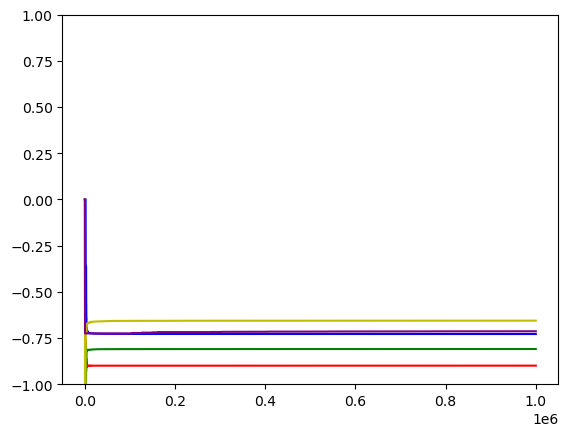

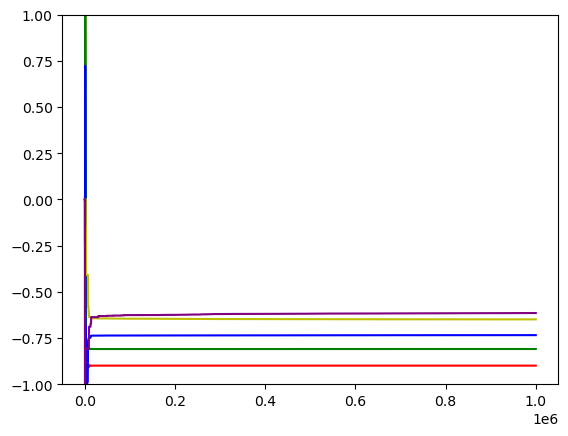

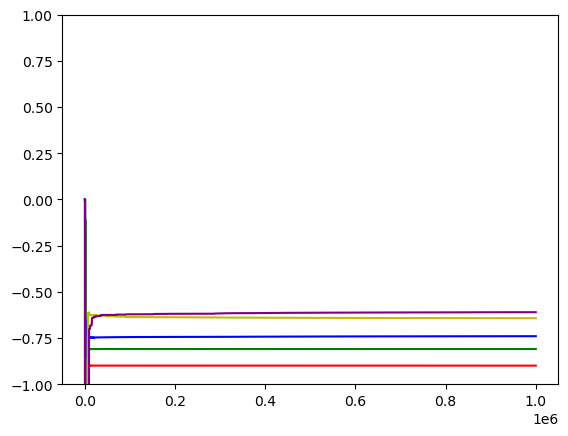

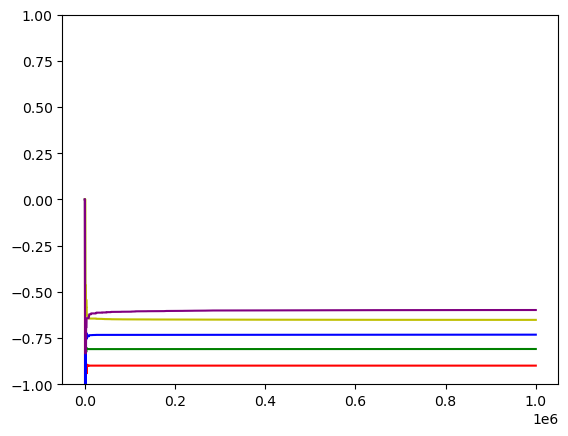

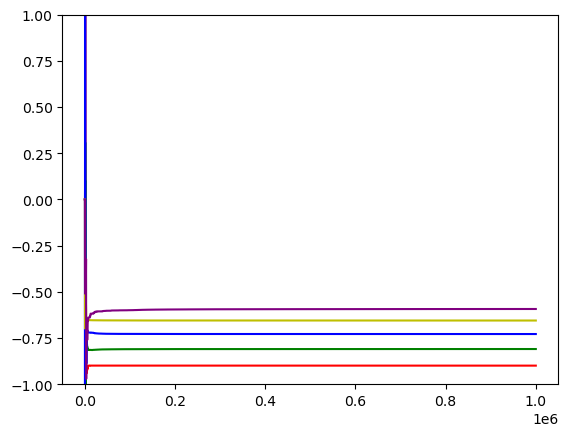

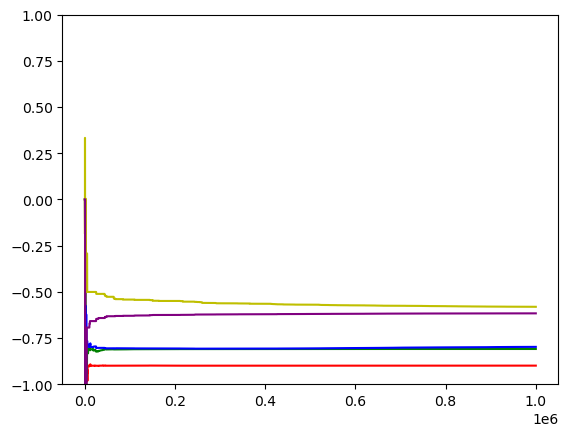

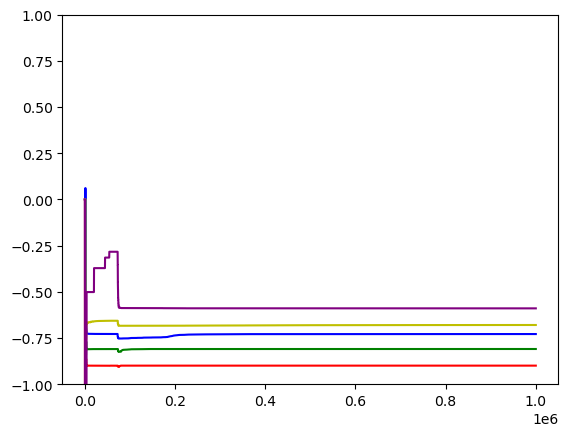

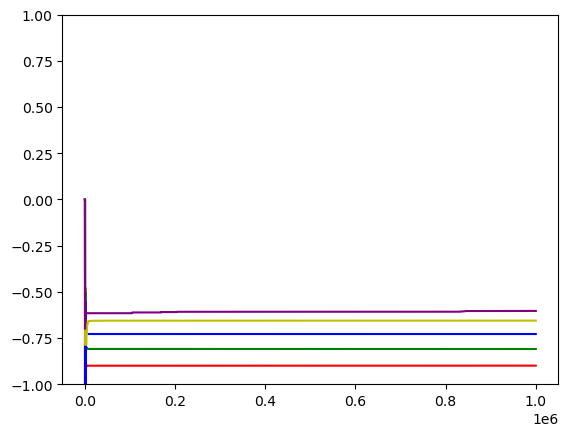

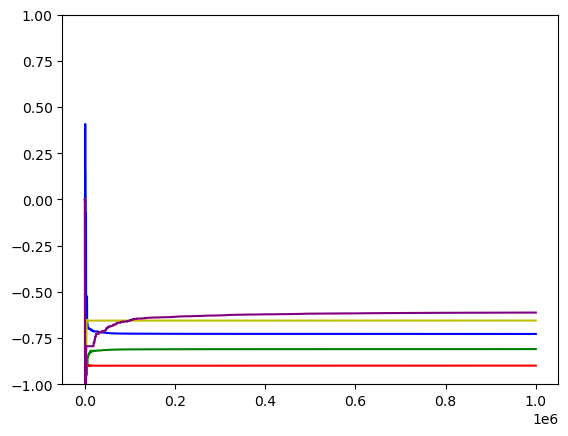

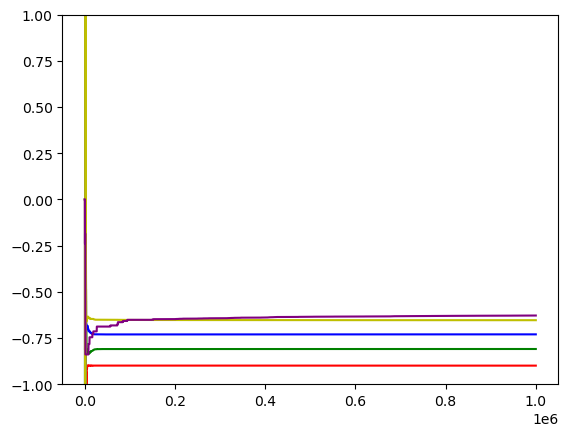

In [14]:
t=1000000
for j in range(N):
    state1=[whittle_indexes_over_time[i][j][0] for i in range(t)]
    state2=[whittle_indexes_over_time[i][j][1] for i in range(t)]
    state3=[whittle_indexes_over_time[i][j][2] for i in range(t)]
    state4=[whittle_indexes_over_time[i][j][3] for i in range(t)]
    state5=[whittle_indexes_over_time[i][j][4] for i in range(t)]
    plt.figure()
    plt.plot(state1,color='r')
    plt.plot(state2,color='g')
    plt.plot(state3,color='b')
    plt.plot(state4,color='y')
    plt.plot(state5,color='purple')
    plt.ylim([-1,1])
    plt.show()